In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
#графики без нового окна

np.random.seed(2024)

N = 3000  # количество заказов

cities = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Челябинск"]
categories = ["Электроника", "Одежда", "Дом", "Красота", "Спорт"]
statuses = ["Доставлен", "Отменён", "Возврат"]
payments = ["Карта", "Онлайн", "Наличные"]

order_id = np.arange(1, N + 1) #айди заказов

order_date = pd.to_datetime("2024-01-01") + pd.to_timedelta(np.random.randint(0, 365, N), unit="D")
#даты заказов

customer_id = np.random.randint(1, 1001, N) #1000 клиентов

city = np.random.choice(cities, N) #выбирает город для заказа

age = np.random.randint(16, 75, N).astype(float) #возраст

is_vip = np.random.choice([True, False], N, p=[0.15, 0.85]) #вип заказ или нет

product_names = [
    "Смартфон", "Ноутбук", "Наушники", "Планшет", "Телевизор",
    "Футболка", "Джинсы", "Куртка", "Платье", "Кроссовки",
    "Кресло", "Стол", "Лампа", "Подушка", "Ковер",
    "Крем", "Шампунь", "Помада", "Духи", "Маска",
    "Гантели", "Коврик", "Мяч", "Велосипед", "Скакалка"] #какие бывают продукты
product_name = np.random.choice(product_names, N) #продукты по заказам
category = np.random.choice(categories, N) #категории к ним

quantity = np.random.randint(1, 6, N) #кол товаров

price = np.random.randint(500, 50000, N) #цена

discount = np.round(np.random.uniform(0, 0.4, N), 2) #скидки

cost = (price * np.random.uniform(0.4, 0.9, N)).round() #себестоимость

status = np.random.choice(statuses, N, p=[0.8, 0.1, 0.1]) #статус заказов

payment = np.random.choice(payments, N) #способ оплаты

In [2]:
df = pd.DataFrame({
    "order_id": order_id,
    "order_date": order_date,
    "customer_id": customer_id,
    "city": city,
    "age": age,
    "is_vip": is_vip,
    "product_name": product_name,
    "category": category,
    "quantity": quantity,
    "price": price,
    "discount": discount,
    "cost": cost,
    "status": status,
    "payment": payment})

print(df.head())

missing_idx = np.random.choice(df.index, 30, replace=False) #30 индексов без повторов
df.loc[missing_idx, "age"] = np.nan #присваиваем NaN

print("Пропусков в age:", df["age"].isna().sum()) #проверка пропусков

   order_id order_date  customer_id       city   age  is_vip product_name  \
0         1 2024-05-16          766  Челябинск  61.0   False    Велосипед   
1         2 2024-04-06          961  Челябинск  67.0    True     Футболка   
2         3 2024-05-08          851  Челябинск  35.0   False       Джинсы   
3         4 2024-01-28          838  Челябинск  61.0   False        Лампа   
4         5 2024-02-06          507  Челябинск  16.0   False        Лампа   

  category  quantity  price  discount     cost     status   payment  
0  Красота         5  42044      0.35  21696.0  Доставлен     Карта  
1  Красота         5   6161      0.18   3556.0  Доставлен     Карта  
2    Спорт         2    566      0.22    231.0  Доставлен     Карта  
3  Красота         1  25365      0.34  12814.0  Доставлен     Карта  
4    Спорт         3  18315      0.08  15871.0  Доставлен  Наличные  
Пропусков в age: 30


## Часть 0. Подготовка данных

Сгенерирован DataFrame из 3000 заказов с 14 столбцами:
order_id, order_date, customer_id, city, age, is_vip, product_name,
category, quantity, price, discount, cost, status, payment.

В столбец age искусственно добавлено 30 пропущенных значений (NaN).

In [3]:
print("Размер таблицы:")
print(df.shape)

print("\nИнформация о таблице:")
df.info()

print("\nПервые 5 строк:")
print(df.head())

print("\nПоследние 5 строк:")
print(df.tail())

print("\nОписательная статистика:")
print(df.describe())

print("\nПропуски:")
print(df.isna().sum())

Размер таблицы:
(3000, 14)

Информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3000 non-null   int64         
 1   order_date    3000 non-null   datetime64[ns]
 2   customer_id   3000 non-null   int64         
 3   city          3000 non-null   object        
 4   age           2970 non-null   float64       
 5   is_vip        3000 non-null   bool          
 6   product_name  3000 non-null   object        
 7   category      3000 non-null   object        
 8   quantity      3000 non-null   int64         
 9   price         3000 non-null   int64         
 10  discount      3000 non-null   float64       
 11  cost          3000 non-null   float64       
 12  status        3000 non-null   object        
 13  payment       3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64

In [4]:
print(df["customer_id"].nunique()) #Уникальных клиентов, кол
print(df["product_name"].nunique()) #Уникальных товаров
print(df["city"].unique()) #Города, списком
print(df["category"].unique()) #Категории
print(df["payment"].unique()) #Способы оплаты

951
25
['Челябинск' 'Санкт-Петербург' 'Екатеринбург' 'Москва' 'Казань']
['Красота' 'Спорт' 'Дом' 'Электроника' 'Одежда']
['Карта' 'Наличные' 'Онлайн']


## Часть 1. Первичный анализ данных

Ответы на вопросы:
1. В DataFrame 3000 строк и 14 столбцов.
2. Пропуски есть только в столбце age.
3. Пропусков в age: 30.
4. Уникальных клиентов: 951.
5. Уникальных товаров: 25.
6. Города: Челябинск, Санкт-Петербург, Екатеринбург, Москва, Казань.
7. Категории: Красота, Спорт, Дом, Электроника, Одежда.
8. Способы оплаты: Карта, Наличные, Онлайн.

In [5]:
df["order_date"] = pd.to_datetime(df["order_date"]) #превращаем строку в дату
df["year"] = df["order_date"].dt.year #вытаскиваем год
df["month"] = df["order_date"].dt.month #вытаскиваем месяц

print(df[["order_date", "year", "month"]].head())

  order_date  year  month
0 2024-05-16  2024      5
1 2024-04-06  2024      4
2 2024-05-08  2024      5
3 2024-01-28  2024      1
4 2024-02-06  2024      2


## 2.1. Работа с датой

Столбец order_date преобразован в тип datetime через pd.to_datetime().
Созданы отдельные столбцы year и month через .dt.year и .dt.month.
Все заказы относятся к 2024 году.

In [6]:
df["revenue"] = df["price"] * df["quantity"] * (1 - df["discount"]) #новвый столбец с выручкой
df["profit"] = df["revenue"] - df["cost"] #прибыль
print(df[["price", "quantity", "discount", "revenue", "cost", "profit"]].head())

   price  quantity  discount    revenue     cost     profit
0  42044         5      0.35  136643.00  21696.0  114947.00
1   6161         5      0.18   25260.10   3556.0   21704.10
2    566         2      0.22     882.96    231.0     651.96
3  25365         1      0.34   16740.90  12814.0    3926.90
4  18315         3      0.08   50549.40  15871.0   34678.40


## 2.2. Расчёт выручки и прибыли

Созданы столбцы:
- revenue = price × quantity × (1 − discount) — выручка с учётом скидки.
- profit = revenue − cost — прибыль.

Прибыль может быть отрицательной, потому что cost генерировался
как 40–90% от price без учёта скидки. Если скидка большая (например,
40%), выручка падает до 60% от цены, и она может оказаться ниже
себестоимости — заказ становится убыточным.

In [7]:
df["is_real_sale"] = df["status"] == "Доставлен" #новый столбец реальная продажа

print("Доставленных заказов:", df["is_real_sale"].sum())
print("Всего заказов:", len(df))

Доставленных заказов: 2418
Всего заказов: 3000


## 2.3. Реальная продажа

Создан признак is_real_sale = (status == "Доставлен").
Он равен True только для доставленных заказов.

Ответ на вопрос: при расчёте фактической выручки учитывают только
доставленные заказы, потому что отменённые и возвращённые заказы
не приносят денег. Отменённый — клиент не заплатил. Возврат — деньги
вернули клиенту. Только доставленный заказ = реальная продажа.

In [8]:
median_age = df["age"].median()
print(median_age) #Медианный возраст

df["age"] = df["age"].fillna(median_age) #заполняет все NaN этим числом

print(df["age"].isna().sum()) #пропусков после заполнения

45.5
0


## 2.4. Пропуски в возрасте

Медианный возраст клиентов: 45.5 лет. Пропуски в age (30 штук)
заполнены этим значением через fillna(median_age). После заполнения
пропусков: 0.

Медиана выбрана вместо среднего, потому что она устойчива к выбросам
и лучше описывает типичное значение.

In [9]:
bins = [0, 18, 30, 45, 60, 100] #границы интервалов
labels = ["ДО 18", "18-30", "31-45", "46-60", "60+"] #сами интервалы

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels) #новый столбец с группами по возрасту

print(df["age_group"].value_counts()) #сколько заказов в каждой группе

age_group
46-60    779
31-45    747
60+      736
18-30    590
ДО 18    148
Name: count, dtype: int64


## 2.5. Возрастные группы

Через pd.cut() возраст разбит на 5 групп: ДО 18, 18-30, 31-45,
46-60, 60+. Распределение заказов по группам:
- 46-60: 779
- 31-45: 747
- 60+: 736
- 18-30: 590
- ДО 18: 148

Больше всего заказов у клиентов 46-60 лет, меньше всего —
у клиентов младше 18 лет.

In [10]:
print("Задание 1. Заказы, где количество товаров больше 3:")
print(df[df["quantity"] > 3].head())

print("Задание 2. Заказы клиентов из Москвы:")
print(df[df["city"] == "Москва"].head())

print("Задание 3. VIP-заказы:")
print(df[df["is_vip"]].head())

print("Задание 4. Заказы, где цена товара больше 5000:")
print(df[df["price"] > 5000].head())

print("Задание 5. Заказы со скидкой больше 20%:")
print(df[df["discount"] > 0.20].head())

print("Количество заказов каждого статуса:")
print(df["status"].value_counts())

Задание 1. Заказы, где количество товаров больше 3:
   order_id order_date  customer_id             city   age  is_vip  \
0         1 2024-05-16          766        Челябинск  61.0   False   
1         2 2024-04-06          961        Челябинск  67.0    True   
6         7 2024-10-24          919  Санкт-Петербург  27.0   False   
8         9 2024-11-12          542     Екатеринбург  51.0   False   
9        10 2024-08-15           40           Москва  23.0   False   

  product_name     category  quantity  price  discount     cost     status  \
0    Велосипед      Красота         5  42044      0.35  21696.0  Доставлен   
1     Футболка      Красота         5   6161      0.18   3556.0  Доставлен   
6      Шампунь        Спорт         4  47676      0.38  27407.0    Возврат   
8      Подушка  Электроника         4  10719      0.24   6487.0  Доставлен   
9     Смартфон       Одежда         5  36529      0.30  20901.0  Доставлен   

    payment  year  month    revenue     profit  is_real_sa

## Часть 3. Фильтрация данных

Задания 1–6 выполнены. Через df[df["столбец"] > значение]
получены выборки по одному условию:
1. quantity > 3 — заказы с количеством больше 3.
2. city == "Москва" — заказы из Москвы.
3. is_vip == True — VIP-заказы.
4. price > 5000 — дорогие товары.
5. discount > 0.20 — заказы со скидкой больше 20%.

Задание 6: value_counts() показал распределение статусов заказов.

In [11]:
task7 = df[(df["city"] == "Москва") & (df["revenue"] > 5000)]
print("Задание 7:", len(task7), "заказов")
print(task7.head())

Задание 7: 567 заказов
    order_id order_date  customer_id    city   age  is_vip product_name  \
9         10 2024-08-15           40  Москва  23.0   False     Смартфон   
11        12 2024-11-18          352  Москва  72.0    True       Кресло   
24        25 2024-11-25          848  Москва  53.0   False      Шампунь   
26        27 2024-08-06          565  Москва  70.0   False        Лампа   
33        34 2024-12-08          359  Москва  67.0    True     Наушники   

       category  quantity  price  discount     cost     status   payment  \
9        Одежда         5  36529      0.30  20901.0  Доставлен     Карта   
11  Электроника         4  39222      0.27  25918.0  Доставлен  Наличные   
24        Спорт         2  42931      0.35  31218.0    Возврат  Наличные   
26       Одежда         4   7522      0.30   5749.0  Доставлен    Онлайн   
33      Красота         1  46646      0.27  40247.0  Доставлен    Онлайн   

    year  month    revenue     profit  is_real_sale age_group  
9   2

In [12]:
task8 = df[(df["is_vip"]) & (df["category"] == "Электроника")]
print("\nЗадание 8:", len(task8), "заказов")
print(task8.head())


Задание 8: 88 заказов
     order_id order_date  customer_id             city   age  is_vip  \
11         12 2024-11-18          352           Москва  72.0    True   
40         41 2024-03-27          380           Казань  69.0    True   
63         64 2024-07-07          209  Санкт-Петербург  64.0    True   
92         93 2024-01-04          820           Казань  61.0    True   
148       149 2024-02-22          804        Челябинск  69.0    True   

    product_name     category  quantity  price  discount     cost     status  \
11        Кресло  Электроника         4  39222      0.27  25918.0  Доставлен   
40         Лампа  Электроника         2   9696      0.07   5549.0    Возврат   
63         Маска  Электроника         4  21459      0.07  13413.0  Доставлен   
92      Смартфон  Электроника         5  24737      0.36  12590.0  Доставлен   
148         Духи  Электроника         5  11511      0.10   8951.0  Доставлен   

      payment  year  month    revenue    profit  is_real_sale a

In [13]:
task9 = df[(df["status"] == "Доставлен") & (df["payment"] == "Онлайн")]
print("\nЗадание 9:", len(task9), "заказов")
print(task9.head())


Задание 9: 814 заказов
    order_id order_date  customer_id             city   age  is_vip  \
7          8 2024-05-07          803        Челябинск  54.0   False   
10        11 2024-03-15          903     Екатеринбург  32.0   False   
13        14 2024-09-04          363           Казань  44.0   False   
14        15 2024-07-21          531  Санкт-Петербург  59.0   False   
19        20 2024-04-01          454  Санкт-Петербург  23.0   False   

   product_name     category  quantity  price  discount     cost     status  \
7          Крем          Дом         3  41559      0.30  29198.0  Доставлен   
10     Смартфон          Дом         4  24034      0.19  13312.0  Доставлен   
13    Велосипед      Красота         3  44386      0.38  23400.0  Доставлен   
14       Коврик  Электроника         3  18580      0.35  12245.0  Доставлен   
19       Платье       Одежда         3  33594      0.36  19145.0  Доставлен   

   payment  year  month   revenue    profit  is_real_sale age_group  
7   

In [14]:
task10 = df[df["year"] == 2024]
print("\nЗадание 10:", len(task10), "заказов")


Задание 10: 3000 заказов


In [15]:
task11 = df[(df["year"] == 2024) & (df["month"] == 1)]
print("\nЗадание 11:", len(task11), "заказов")
print(task11.head())


Задание 11: 279 заказов
    order_id order_date  customer_id             city   age  is_vip  \
3          4 2024-01-28          838        Челябинск  61.0   False   
17        18 2024-01-12           47        Челябинск  54.0   False   
52        53 2024-01-23          844        Челябинск  28.0   False   
58        59 2024-01-30           77  Санкт-Петербург  19.0   False   
59        60 2024-01-23          250           Казань  58.0   False   

   product_name category  quantity  price  discount     cost     status  \
3         Лампа  Красота         1  25365      0.34  12814.0  Доставлен   
17        Лампа    Спорт         4  23258      0.33  13840.0  Доставлен   
52     Скакалка    Спорт         1  21030      0.13   9941.0  Доставлен   
58         Стол   Одежда         4   5140      0.24   3640.0    Отменён   
59         Стол      Дом         2  41719      0.31  31509.0    Отменён   

     payment  year  month   revenue    profit  is_real_sale age_group  
3      Карта  2024      1

## Сложные фильтры (задания 7–11)

Использованы фильтры с двумя условиями через &:
7. Москва + revenue > 5000.
8. VIP + категория «Электроника».
9. status == "Доставлен" + payment == "Онлайн".
10. year == 2024 → 3000 заказов.
11. year == 2024 + month == 1 → 279 заказов за январь.

In [16]:
print(df.loc[df["revenue"].idxmax()]) #Заказ с максимальной выручкой

order_id                        421
order_date      2024-03-29 00:00:00
customer_id                     308
city                         Казань
age                            47.0
is_vip                        False
product_name              Кроссовки
category                    Красота
quantity                          5
price                         49688
discount                       0.03
cost                        37109.0
status                    Доставлен
payment                      Онлайн
year                           2024
month                             3
revenue                    240986.8
profit                     203877.8
is_real_sale                   True
age_group                     46-60
Name: 420, dtype: object


In [17]:
print(df.loc[df["discount"].idxmax()]) #Заказ с максимальной скидкой

order_id                        142
order_date      2024-01-26 00:00:00
customer_id                     945
city                   Екатеринбург
age                            64.0
is_vip                        False
product_name                    Мяч
category                        Дом
quantity                          4
price                         49002
discount                        0.4
cost                        39318.0
status                      Возврат
payment                       Карта
year                           2024
month                             1
revenue                    117604.8
profit                      78286.8
is_real_sale                  False
age_group                       60+
Name: 141, dtype: object


In [18]:
print(df.loc[df["profit"].idxmax()]) #Заказ с максимальной прибылью

order_id                       1892
order_date      2024-06-22 00:00:00
customer_id                     145
city                   Екатеринбург
age                            51.0
is_vip                        False
product_name                 Помада
category                      Спорт
quantity                          5
price                         47846
discount                       0.01
cost                        20171.0
status                      Отменён
payment                    Наличные
year                           2024
month                             6
revenue                    236837.7
profit                     216666.7
is_real_sale                  False
age_group                     46-60
Name: 1891, dtype: object


In [19]:
print(df.loc[df["age"].idxmin()]) #Самый молодой клиент

order_id                          5
order_date      2024-02-06 00:00:00
customer_id                     507
city                      Челябинск
age                            16.0
is_vip                        False
product_name                  Лампа
category                      Спорт
quantity                          3
price                         18315
discount                       0.08
cost                        15871.0
status                    Доставлен
payment                    Наличные
year                           2024
month                             2
revenue                     50549.4
profit                      34678.4
is_real_sale                   True
age_group                     ДО 18
Name: 4, dtype: object


In [20]:
print(df.loc[df["age"].idxmax()]) #Самый старший клиент

order_id                         28
order_date      2024-09-01 00:00:00
customer_id                     464
city                      Челябинск
age                            74.0
is_vip                        False
product_name                  Маска
category                     Одежда
quantity                          2
price                          4217
discount                       0.03
cost                         3726.0
status                    Доставлен
payment                      Онлайн
year                           2024
month                             9
revenue                     8180.98
profit                      4454.98
is_real_sale                   True
age_group                       60+
Name: 27, dtype: object


## Поиск экстремальных значений

Через idxmax() и idxmin() найдены:
1. Заказ с максимальной выручкой.
2. Заказ с максимальной скидкой.
3. Заказ с максимальной прибылью.
4. Самый молодой клиент: возраст 16 лет, группа «ДО 18».
5. Самый старший клиент: возраст 74 года, группа «60+».

Метод .loc[] используется для получения полной строки по индексу,
найденному через idxmax()/idxmin().

In [21]:
task1 = df.groupby("category")["revenue"].sum()  #суммарная выручка по категориям
print(task1)
print(task1.idxmax())  #категория лидер

category
Дом            37749460.69
Красота        35015879.89
Одежда         32558774.60
Спорт          39494400.89
Электроника    34696032.71
Name: revenue, dtype: float64
Спорт


In [22]:
task2 = df.groupby("category")["revenue"].mean()  #средняя выручка по категориям
print(task2)

category
Дом            59075.838326
Красота        60268.295852
Одежда         56623.955826
Спорт          63393.901910
Электроника    59615.176478
Name: revenue, dtype: float64


In [23]:
task3 = df.groupby("category")["order_id"].count()  #количество заказов по категориям
print(task3)

category
Дом            639
Красота        581
Одежда         575
Спорт          623
Электроника    582
Name: order_id, dtype: int64


In [24]:
task4 = df.groupby("category")["discount"].mean()  #средняя скидка по категориям
print(task4)

category
Дом            0.201111
Красота        0.196248
Одежда         0.207078
Спорт          0.199230
Электроника    0.195292
Name: discount, dtype: float64


In [25]:
task5 = df.groupby(["category", "city"])["revenue"].sum()  #выручка по категории и городу
print(task5.head(10))

category  city           
Дом       Екатеринбург       7483330.59
          Казань             7311754.89
          Москва             6559177.38
          Санкт-Петербург    7274521.27
          Челябинск          9120676.56
Красота   Екатеринбург       6774379.08
          Казань             7163451.00
          Москва             7557137.39
          Санкт-Петербург    7471576.51
          Челябинск          6049335.91
Name: revenue, dtype: float64


In [26]:
task6 = df[df["is_vip"]].groupby("city")["revenue"].mean()  #средняя выручка VIP по городам
print(task6)

city
Екатеринбург       50083.544943
Казань             57535.367253
Москва             52890.390000
Санкт-Петербург    54715.550333
Челябинск          54248.458804
Name: revenue, dtype: float64


In [27]:
task7 = df.groupby(["city", "payment"])["order_id"].count()  #заказы по городам и оплатам
print(task7.head(10))

city             payment 
Екатеринбург     Карта       202
                 Наличные    191
                 Онлайн      214
Казань           Карта       200
                 Наличные    202
                 Онлайн      201
Москва           Карта       191
                 Наличные    199
                 Онлайн      201
Санкт-Петербург  Карта       190
Name: order_id, dtype: int64


In [28]:
task8 = df.groupby("category").agg(  #несколько показателей по категориям
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_discount=("discount", "mean"),
    profit=("profit", "sum"))
print(task8)

             orders      revenue   avg_revenue  avg_discount       profit
category                                                                 
Дом             639  37749460.69  59075.838326      0.201111  27535878.69
Красота         581  35015879.89  60268.295852      0.196248  25751806.89
Одежда          575  32558774.60  56623.955826      0.207078  23144134.60
Спорт           623  39494400.89  63393.901910      0.199230  29164159.89
Электроника     582  34696032.71  59615.176478      0.195292  25248510.71


## Часть 4. Группировка данных

Задания 1–8 выполнены с помощью groupby():

1. Выручка по категориям.
2. Средняя выручка по категориям.
3. Количество заказов по категориям.
4. Средняя скидка по категориям.
5. Выручка по категории и городу (groupby по двум столбцам).
6. Средняя выручка VIP-заказов по городам — максимум у Казани (57535).
7. Количество заказов по городам и способам оплаты — распределение
   почти равномерное.
8. Сводная таблица через agg(): количество заказов, суммарная и средняя
   выручка, средняя скидка, суммарная прибыль по категориям.

По суммарной выручке лидирует категория «Спорт» (39.5 млн руб.),
по количеству заказов — «Дом» (639). Средняя скидка во всех категориях
близка к 0.20.

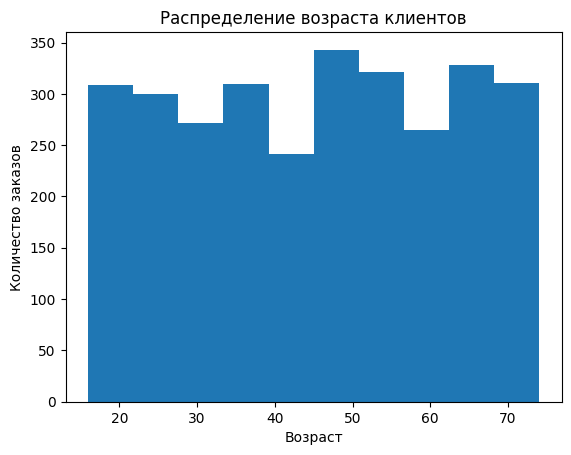

In [29]:
plt.hist(df["age"], bins=10)  #гистограмма возраста
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.show()

## Часть 5. Визуализация

### Задание 1. Распределение возраста

Гистограмма возраста клиентов показывает равномерное распределение
в диапазоне 16–74 лет. Клиенты всех возрастов делают заказы примерно
с одинаковой частотой, ярко выраженных пиков нет.

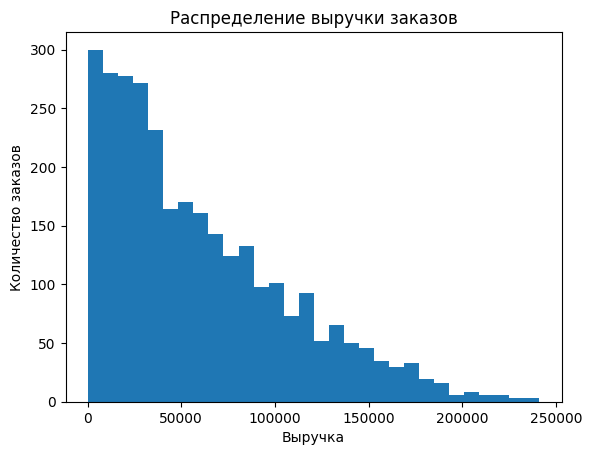

In [30]:
plt.hist(df["revenue"], bins=30)  #гистограмма выручки
plt.title("Распределение выручки заказов")
plt.xlabel("Выручка")
plt.ylabel("Количество заказов")
plt.show()

### Задание 2. Распределение выручки

Гистограмма выручки показывает правостороннее распределение
с длинным хвостом. Большинство заказов имеют выручку до 50 000 руб.,
самый высокий пик — около 0–10 000. Чем выше выручка, тем меньше
таких заказов. Максимальная выручка — около 250 000 руб.

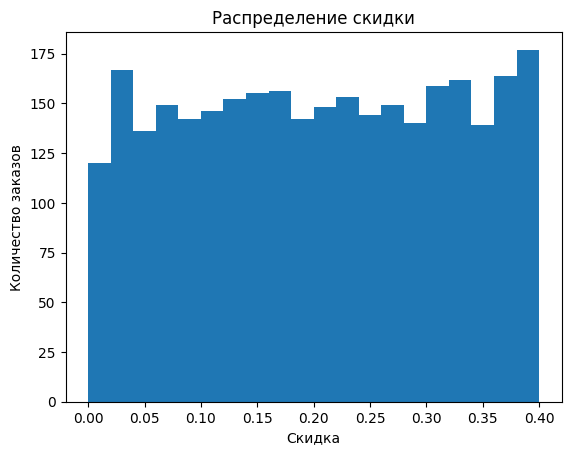

In [31]:
plt.hist(df["discount"], bins=20)  # гистограмма скидки
plt.title("Распределение скидки")
plt.xlabel("Скидка")
plt.ylabel("Количество заказов")
plt.show()

### Задание 3. Распределение скидки

Гистограмма скидки показывает равномерное распределение в диапазоне
0–0.4. Столбики примерно одинаковой высоты, пиков нет. Это ожидаемо,
потому что скидка генерировалась через np.random.uniform(0, 0.4, N).

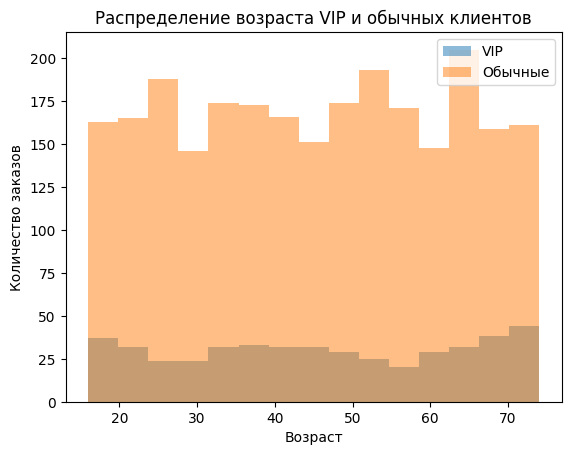

In [32]:
plt.hist(df[df["is_vip"]]["age"], bins=15, alpha=0.5, label="VIP")  # возраст VIP
plt.hist(df[~df["is_vip"]]["age"], bins=15, alpha=0.5, label="Обычные")  # возраст обычных
plt.title("Распределение возраста VIP и обычных клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.legend()  # показать легенду
plt.show()

### Задание 4. VIP и обычные клиенты

Распределение возраста VIP и обычных клиентов практически
одинаковое — примерно равномерное от 16 до 74 лет. VIP-заказов
около 15% от общего числа. Возраст не влияет на то, является
ли клиент VIP, потому что эти признаки генерировались независимо.

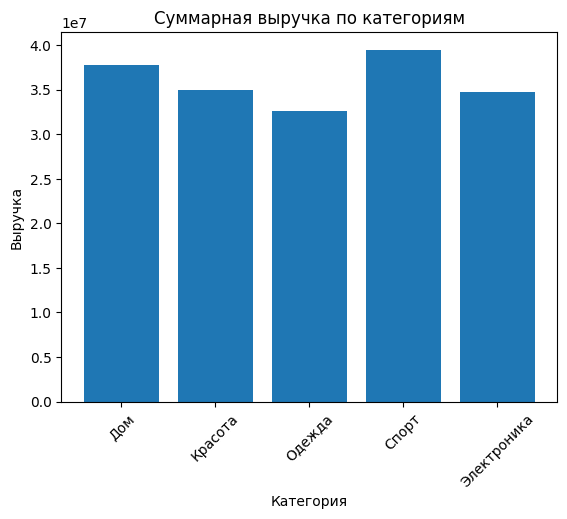

In [33]:
revenue_by_cat = df.groupby("category")["revenue"].sum()  # суммарная выручка
plt.bar(revenue_by_cat.index, revenue_by_cat.values)  # столбчатая диаграмма
plt.title("Суммарная выручка по категориям")
plt.xlabel("Категория")
plt.ylabel("Выручка")
plt.xticks(rotation=45)  # наклон подписей оси X
plt.show()

### Задание 5. Выручка по категориям

Столбчатая диаграмма показывает суммарную выручку по категориям:
- Спорт: ≈ 39.5 млн (лидер)
- Дом: ≈ 37.7 млн
- Красота: ≈ 35.0 млн
- Электроника: ≈ 34.7 млн
- Одежда: ≈ 32.6 млн (минимум)

Все категории близки по выручке — разница между лидером
и минимумом около 20%.

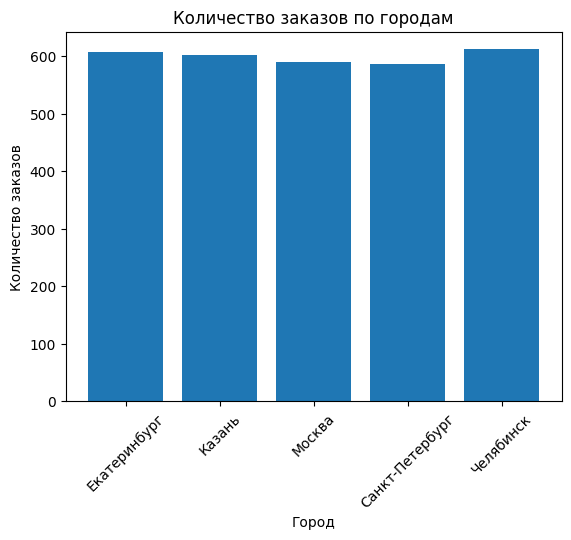

In [34]:
orders_by_city = df.groupby("city")["order_id"].count()  # заказы по городам
plt.bar(orders_by_city.index, orders_by_city.values)  # столбчатая диаграмма
plt.title("Количество заказов по городам")
plt.xlabel("Город")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)  # наклон подписей
plt.show()

### Задание 6. Заказы по городам

Количество заказов по городам почти одинаковое — около 600 на
каждый город. Это ожидаемо, потому что город выбирался случайно
с равной вероятностью для всех городов. Лидер — Челябинск (~615),
минимум — Москва и Санкт-Петербург (~590).

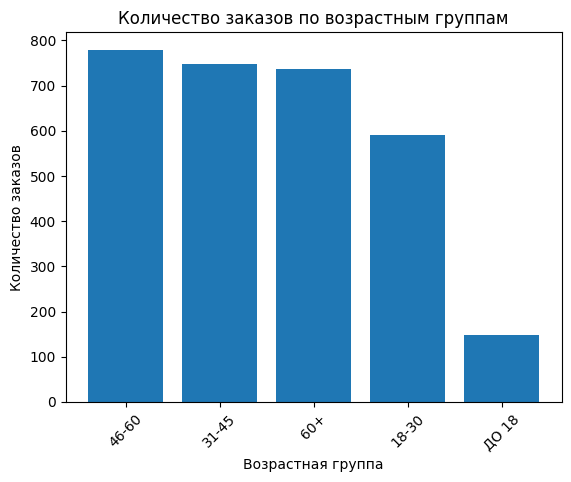

In [35]:
age_group_counts = df["age_group"].value_counts()  # количество по возрастным группам
plt.bar(age_group_counts.index, age_group_counts.values)  # столбчатая диаграмма
plt.title("Количество заказов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.show()

### Задание 7. Возрастные группы

Больше всего заказов у клиентов 46-60 лет (~780). Группа «ДО 18»
самая маленькая (~148), потому что охватывает всего 2 года (16-17 лет),
в то время как остальные группы — по 15 лет.

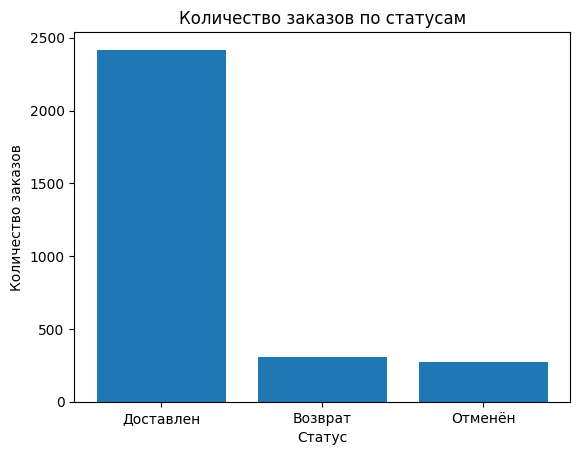

In [36]:
status_counts = df["status"].value_counts()  # количество по статусам
plt.bar(status_counts.index, status_counts.values)  # столбчатая диаграмма
plt.title("Количество заказов по статусам")
plt.xlabel("Статус")
plt.ylabel("Количество заказов")
plt.show()

### Задание 8. Статусы заказов

Подавляющее большинство заказов (~2418 из 3000, ≈ 80%) имеют статус
«Доставлен». Отменённых и возвращённых — примерно по 10% каждый.
Это соответствует параметрам генерации: p=[0.8, 0.1, 0.1].

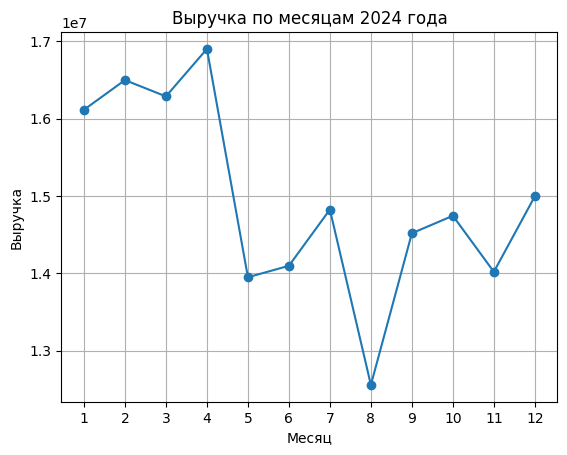

In [37]:
monthly = df.groupby(["year", "month"])["revenue"].sum()  # выручка по месяцам
plt.plot(monthly.index.get_level_values("month"), monthly.values, marker="o")  # линейный график
plt.title("Выручка по месяцам 2024 года")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.xticks(range(1, 13))  # все 12 месяцев на оси X
plt.grid(True)  # сетка для читаемости
plt.show()

### Задание 9. Выручка по месяцам

График показывает колебания выручки от 12.5 до 17 млн руб.
Максимум - в апреле (16.9 млн), минимум - в августе (12.5 млн).
Явного тренда или сезонности нет: различия между месяцами
объясняются случайным характером генерации данных.

In [38]:
print("Общее количество заказов:", len(df))  #количество заказов
print("Общая выручка:", df["revenue"].sum())  #суммарная выручка
print("Средняя выручка заказа:", df["revenue"].mean())  #средняя выручка

Общее количество заказов: 3000
Общая выручка: 179514548.77999997
Средняя выручка заказа: 59838.182926666654


In [39]:
print(df.groupby("category")["revenue"].sum().idxmax())  #категория-лидер

print(df.groupby("category")["revenue"].sum().idxmin())  #категория-аутсайдер

Спорт
Одежда


In [40]:
print(df.loc[df["is_vip"], "revenue"].sum() / df["revenue"].sum() * 100)  #% выручки VIP

13.901912078772071


In [41]:
df["discount_group"] = pd.cut(
    df["discount"],
    bins=[0, 0.1, 0.2, 0.3, 0.4],
    labels=["0-10%", "10-20%", "20-30%", "30-40%"]
)  #разбиваем скидку на группы

print(df.groupby("discount_group", observed=True)["revenue"].mean())  #средняя выручка по группам скидок

discount_group
0-10%     70694.149748
10-20%    63833.990732
20-30%    54658.837019
30-40%    49569.970818
Name: revenue, dtype: float64


In [42]:
print(df[df["status"].isin(["Отменён", "Возврат"])].groupby("category")["order_id"].count().sort_values(ascending=False))  #плохие заказы по категориям

category
Дом            138
Электроника    119
Спорт          116
Одежда         106
Красота        103
Name: order_id, dtype: int64


## Часть 6. Мини-анализ

### Задание 1. Общая статистика
Общее количество заказов: 3000.
Общая выручка: 179 514 548 руб.
Средняя выручка заказа: 59 838 руб.
Вывод: в среднем заказ приносит около 60 тыс. руб. Среднее
значение выше медианы из-за крупных заказов.

### Задание 2. Категории
Категория с максимальной выручкой: Спорт.
Категория с минимальной выручкой: Одежда.
Вывод: разница между лидером и аутсайдером около 20%. Все
категории приносят сопоставимую выручку.

### Задание 3. VIP-заказы
Доля выручки VIP-заказов: 13.9%.
Вывод: VIP-клиенты дают около 14% выручки. Это значимая,
но не критичная доля. VIP-заказы в среднем чуть дешевле
обычных.

### Задание 4. Скидки
Средняя выручка по группам скидок:
- 0-10%: 70 694 руб.
- 10-20%: 63 834 руб.
- 20-30%: 54 659 руб.
- 30-40%: 49 570 руб.
Вывод: чем больше скидка, тем меньше средняя выручка.
Это математическое следствие формулы revenue = price × quantity × (1 − discount).
Большие скидки снижают выручку с заказа.

### Задание 5. Возвраты и отмены
Плохие заказы по категориям:
- Дом: 138
- Электроника: 119
- Спорт: 116
- Одежда: 106
- Красота: 103
Вывод: отмены и возвраты распределены по категориям почти
равномерно. Категория «Дом» немного выделяется, но это
скорее случайный шум, потому что статус генерировался
независимо от категории.

## Часть 7. Итоговый вывод

В ходе анализа 3000 заказов интернет-магазина выявлено, что
общая выручка составила 179.5 млн рублей при средней выручке
заказа около 60 тыс. рублей. Наиболее значимые по выручке
категории — Спорт и Дом, наименее — Одежда, но разница между
ними невелика (около 20%). Заказы распределены по городам
практически равномерно — около 600 на каждый город. VIP-клиенты
формируют около 14% выручки, что делает их важным, но не
критичным сегментом. Скидки оказывают прямое влияние на выручку:
при скидке 30-40% средняя выручка заказа почти на 30% ниже, чем
при скидке 0-10%. Возвраты и отмены распределены по категориям
равномерно, без явных «проблемных» категорий. В качестве
дополнительного исследования можно изучить зависимость прибыли
от размера скидки — есть ли точка, после которой скидки
становятся убыточными.